In [1]:
import pandas as pd 

In [2]:
train_df = pd.read_csv("../data/train.csv", header=None)
test_df = pd.read_csv("../data/test.csv", header=None)

In [3]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (120000, 3)
Test shape: (7600, 3)


In [4]:
train_df.head()

,0,1,2
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [5]:
train_df.columns = ["class", "title", "description"]
test_df.columns = ["class", "title", "description"]

In [6]:
train_df.head()

,class,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   class        120000 non-null  int64 
 1   title        120000 non-null  object
 2   description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [8]:
print(train_df.isnull().sum())
print(test_df.isnull().sum())

class          0
title          0
description    0
dtype: int64
class          0
title          0
description    0
dtype: int64


In [9]:
print("Duplicate rows:", train_df.duplicated().sum())

Duplicate rows: 0


In [10]:
train_df["text_length"] = train_df["description"].str.len()

print(train_df["text_length"].describe())

count    120000.000000
mean        193.402017
std          64.452006
min          20.000000
25%         155.000000
50%         188.000000
75%         219.000000
max         985.000000
Name: text_length, dtype: float64


In [11]:
for category in sorted(train_df["class"].unique()):
    print("\nCLASS:", category)
    print(train_df[train_df["class"] == category]["title"].head(3).to_string(index=False))


CLASS: 1
Venezuelans Vote Early in Referendum on Chavez ...
S.Koreans Clash with Police on Iraq Troop Dispa...
Palestinians in Israeli Jails Start Hunger Stri...

CLASS: 2
      Phelps, Thorpe Advance in 200 Freestyle (AP)
      Reds Knock Padres Out of Wild-Card Lead (AP)
Dreaming done, NBA stars awaken to harsh Olympi...

CLASS: 3
 Wall St. Bears Claw Back Into the Black (Reuters)
Carlyle Looks Toward Commercial Aerospace (Reut...
   Oil and Economy Cloud Stocks' Outlook (Reuters)

CLASS: 4
'Madden,' 'ESPN' Football Score in Different Wa...
Group to Propose New High-Speed Wireless Format...
AOL to Sell Cheap PCs to Minorities and Seniors...


In [12]:
train_df['text'] = train_df['title'] + ' ' + train_df['description']

In [13]:
test_df['text'] = test_df['title'] + ' ' + test_df['description']

In [14]:
train_df['text'].head()

0    Wall St. Bears Claw Back Into the Black (Reute...
1    Carlyle Looks Toward Commercial Aerospace (Reu...
2    Oil and Economy Cloud Stocks' Outlook (Reuters...
3    Iraq Halts Oil Exports from Main Southern Pipe...
4    Oil prices soar to all-time record, posing new...
Name: text, dtype: object

In [15]:
train_df['text'] = train_df['text'].str.lower()
test_df['text'] = test_df['text'].str.lower()

In [16]:
train_df['text'].head()

0    wall st. bears claw back into the black (reute...
1    carlyle looks toward commercial aerospace (reu...
2    oil and economy cloud stocks' outlook (reuters...
3    iraq halts oil exports from main southern pipe...
4    oil prices soar to all-time record, posing new...
Name: text, dtype: object

In [17]:
import nltk

In [18]:
from nltk.tokenize import word_tokenize
import re
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

In [19]:
train_df['text'] = train_df['text'].apply(clean_text)
test_df['text'] = test_df['text'].apply(clean_text)

In [20]:
train_df['text']

0         wall st bears claw back into the black reuters...
1         carlyle looks toward commercial aerospace reut...
2         oil and economy cloud stocks outlook reuters r...
3         iraq halts oil exports from main southern pipe...
4         oil prices soar to alltime record posing new m...
                                ...                        
119995    pakistans musharraf says wont quit as army chi...
119996    renteria signing a topshelf deal red sox gener...
119997    saban not going to dolphins yet the miami dolp...
119998    todays nfl games pittsburgh at ny giants time ...
119999    nets get carter from raptors indianapolis  all...
Name: text, Length: 120000, dtype: object

In [21]:
from nltk.tokenize import word_tokenize

print(word_tokenize(train_df["text"].iloc[0]))

['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'shortsellers', 'wall', 'streets', 'dwindlingband', 'of', 'ultracynics', 'are', 'seeing', 'green', 'again']


In [22]:
nltk.download("omw-1.4")

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [23]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


In [24]:
lemmaizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [25]:
def preprocessed_text(text):
    text = re.sub(r'[^a-zA-Z\s]',' ',text)

    tokens = word_tokenize(text)

    tokens = [lemmaizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(tokens)

In [26]:
sample = train_df["text"].iloc[0]

print("Before preprocessing:")
print(sample)

print("\nAfter preprocessing:")
print(preprocessed_text(sample))

Before preprocessing:
wall st bears claw back into the black reuters reuters  shortsellers wall streets dwindlingband of ultracynics are seeing green again

After preprocessing:
wall st bear claw back black reuters reuters shortsellers wall street dwindlingband ultracynics seeing green


In [27]:
train_df["processed_text"] = train_df["text"].apply(preprocessed_text)
test_df["processed_text"] = test_df["text"].apply(preprocessed_text)

In [28]:
train_df[["text", "processed_text"]].head()

,text,processed_text
0,wall st bears claw back into the black reuters...,wall st bear claw back black reuters reuters s...
1,carlyle looks toward commercial aerospace reut...,carlyle look toward commercial aerospace reute...
2,oil and economy cloud stocks outlook reuters r...,oil economy cloud stock outlook reuters reuter...
3,iraq halts oil exports from main southern pipe...,iraq halt oil export main southern pipeline re...
4,oil prices soar to alltime record posing new m...,oil price soar alltime record posing new menac...


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
t = TfidfVectorizer(max_features=50000, ngram_range=(1,2))

In [32]:
X_train = t.fit_transform(train_df['processed_text'])
X_test = t.transform(test_df['processed_text'])

In [33]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (120000, 50000)
X_test: (7600, 50000)


In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
y_train = train_df["class"]
y_test = test_df["class"]

In [37]:
y_pred = model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9205263157894736


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.94      0.91      0.92      1900
           2       0.96      0.98      0.97      1900
           3       0.89      0.89      0.89      1900
           4       0.90      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



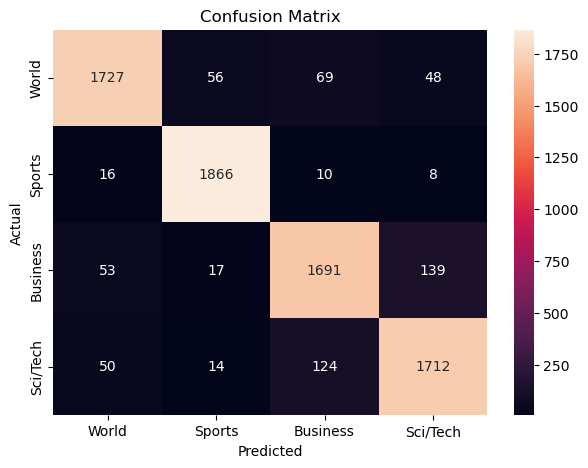

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["World", "Sports", "Business", "Sci/Tech"],
    yticklabels=["World", "Sports", "Business", "Sci/Tech"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [42]:
import joblib

joblib.dump(model, "news_topic_model.pkl")
joblib.dump(t, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']